<a href="https://colab.research.google.com/github/me1-3/Emsc2010-A3/blob/main/Copy_of_a3_oxidised_nitrogen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Introduction:**


**Western Port**

Western port is a large shallow embayment, which is It is surrounded by urban and agricultural lands, such that much of the natural landscape has been altered dramatically [4].

In my study of this location, I drew data forth from the 'EPA Western Port Water Quality Data 1990 - 2025' report to analyse how the local environmental  had changed over time due to man-made factors.

**Data Set**

My original data set was sourced from this site: https://discover.data.vic.gov.au/dataset/epa-western-port-water-quality-data

And I cleaned the dataset to only contain the parameters that I was interested in examining: https://anu365-my.sharepoint.com/:x:/g/personal/u8216285_anu_edu_au/IQDP-tY6SH3uRbwQQZ3TutJZAX8T700pbnxJimA4K-waja4

**Parameter**

Which in this case was Oxidised Nitrogen (NOx). As according to Melbourne Water's report 'Understanding the Western Port Environment', due to catchment run-off from local agriculture, drains and groundwater, there has been a significant increase in NOx. This is most prevelent in Corinella, as it sits in the eastern arm, of which receives a disportionately high amount of nutrient loads from the Bass River - furthermore due to eastern arm having longer residence times, NOx here accumulates more, rather than flushing quickly at other locations [4].

NOx, of which is the mixture of Nitric Oxide (NO) and Nitrogen Dioxide (NO<sub>2</sub>) is large threat towards both people and the environment as long term exposure or elevated levels damages the respitory track, and creates both smog and acid rain [5]. In more coastal environments such Western Port, it can contribute to nutrient pollution - fueling agal blooms [4].

Thereby my project seeks to examine these issues, asking the *question:*

**Research Question & Hypothesis**

*How have concentrations of oxidised nitrogen changed in Western Port Victoria over time, and to what extent do our findings correlate to land useage and/or climate change?*

To which I hypothesise, in accordance to my background research in the topic that:

*The total percent of oxidised nitrogen at Western Port has increased.*


**Map**

To give a frame of reference for the site's we are examining, I have included a map of the area to visualise the spatial distribution  of the site:

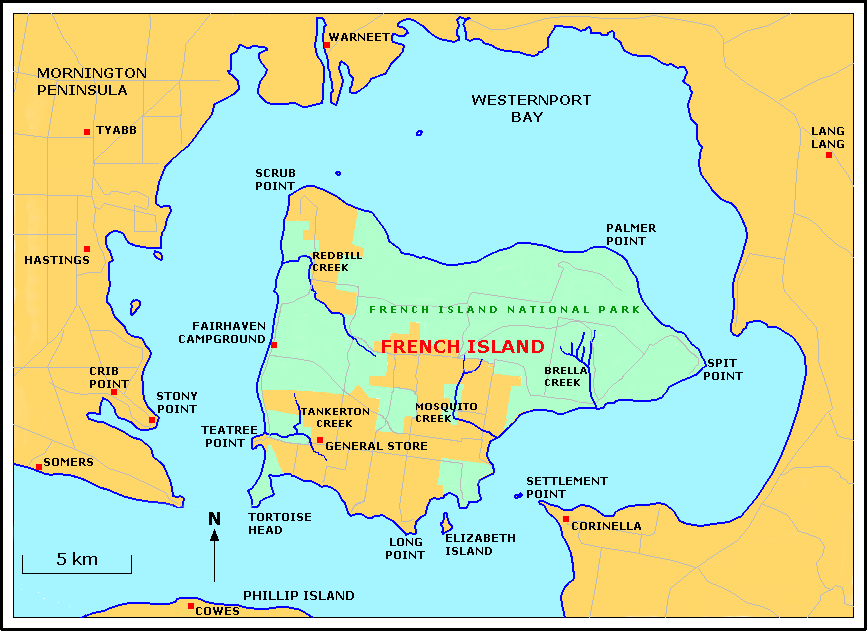

**Meta Data**

As well as provided the following Metadata to summarise the parameters chosen:

<p></p>
<table style="border-collapse: collapse; width: 474pt;" width="632">
<tbody>
<tr style="height: 14.25pt;">
<td class="xl118" style="width: 84pt; height: 14.25pt;" width="112" height="19">Parameter</td>
<td class="xl118" style="width: 114pt;" width="152">method_name</td>
<td class="xl118" style="width: 161pt;" width="215">parameter_name</td>
<td class="xl118" style="width: 115pt;" width="153">units</td>
</tr>
<tr style="height: 14.25pt;">
<td class="xl118" style="width: 84pt; height: 14.25pt;" width="112" height="19">N_NOX</td>
<td class="xl118" style="width: 114pt;" width="152">LAB</td>
<td class="xl118" style="width: 161pt;" width="215">oxidised nitrogen</td>
<td class="xl118" style="width: 115pt;" width="153">mg/L</td>
</tr>
</tbody>
</table><table width="735">
<tbody>
<tr>
<td width="87">site_id</td>
<td width="220">site_name_long</td>
<td width="138">site_name_short</td>
<td width="108">water_body</td>
<td width="98">latitude</td>
<td width="84">longitude</td>
</tr>
<tr>
<td>709</td>
<td>WESTERNPORT BAY&nbsp; MCU #709</td>
<td>Hastings</td>
<td>Western Port</td>
<td>-38.32913208</td>
<td>145.2371063</td>
</tr>
<tr>
<td>724</td>
<td>WESTERNPORT BAY&nbsp; MCU #724</td>
<td>Corinella</td>
<td>Western Port</td>
<td>-38.37223053</td>
<td>145.4830017</td>
</tr>
<tr>
<td>716</td>
<td>WESTERNPORT BAY&nbsp; MCU #716</td>
<td>Barralier Island</td>
<td>Western Port</td>
<td>-38.269905</td>
<td>145.314804</td>
</tr>
</tbody>
</table>
<p>&nbsp;</p>
<div id="gtx-trans" style="position: absolute; left: -31px; top: -20px;">&nbsp;</div>

#**Coding Analysis**

###**Importing Libraries, Loading and Clearing Data:**

In [429]:
#Install Bambi (BAyesian Model-Building Interface) for PyMC to run Bayesian statistical modeling
!pip install bambi

In [430]:
#Import core libraries used for modelling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
import bambi as bmb
import arviz as az
from scipy import stats
import pymc as pm

In [431]:
# Load western port water quality data from my cleaned excel file
spreadsheet_name = "wpdata.xlsx"
worksheet_name = "Data"
df = pd.read_excel(spreadsheet_name, sheet_name=worksheet_name)

#clean the column names - strip spaces, convert to uppercase, replace spaces w/ underscores
df.columns = df.columns.str.strip().str.upper().str.replace(" ", "_")

#Show first 5 rows
df.head()

,SITE_ID,SITE_NAME_SHORT,WATER_BODY,DATE,TYPE,CHL_A,SECCHI_DEPTH_M,DO_MG,FL,PAR,...,PH,TSS,N_NH3,N_NO2,N_NO3,N_NOX,N_TOTAL,P_PO4,P_TOTAL,SI
0,709,Hastings,Western Port,1990-02-28,surface,1.30,2.0,7.18,NaN,NaN,...,NaN,5.09,14.62,1.09,4.92,6.02,181.67,4.73,12.71,96.92
1,716,Barralier Island,Western Port,1990-02-28,surface,1.45,2.0,6.97,NaN,NaN,...,NaN,6.23,12.46,1.12,3.69,4.81,216.92,2.86,13.39,100.34
2,724,Corinella,Western Port,1990-02-28,surface,1.68,1.0,6.33,NaN,NaN,...,NaN,21.91,8.68,0.78,5.34,6.11,265.51,3.80,26.51,19.67
3,724,Corinella,Western Port,1990-04-03,surface,1.48,0.5,7.21,NaN,NaN,...,8.1,14.24,20.74,2.65,9.13,11.77,267.22,6.54,38.24,326.89
4,709,Hastings,Western Port,1990-04-04,surface,1.30,2.0,7.11,NaN,NaN,...,8.2,7.23,9.90,0.97,3.29,4.26,172.10,6.09,27.72,105.31


###**Choosing sites and time based off data cleaning:**


In [403]:
#count the num. of observations per site
df["SITE_NAME_SHORT"].value_counts()

,count
SITE_NAME_SHORT,
Corinella,385
Hastings,380
Barralier Island,265


In [404]:
#Choosing sites with the most observations
loc_types = ["Corinella", "Hastings", "Barralier Island"]
loc_1, loc_2, loc_3 = loc_types
print("Locations used:", loc_types)

Locations used: ['Corinella', 'Hastings', 'Barralier Island']


In [405]:
# Create numeric time variable (year + fraction of year)
df["TIME_FLOAT"] = df["DATE"].dt.year + (df["DATE"].dt.month - 1) / 12

loc_col = "SITE_NAME_SHORT"
x_col = "TIME_FLOAT"
y_col = "N_NOX"

# Filter to the two locations and keep only needed columns
data = df[df[loc_col].isin([loc_1, loc_2, loc_3])].copy()
data = data[[loc_col, x_col, y_col]].dropna()

Data handling:
- Sorting ensures time‑series methods behave correctly.

- Computing mean temperature from min/max is standard practice when hourly data is unavailable.

- Missing values should be checked and removed or imputed depending on context.

##Exploratory Plot:

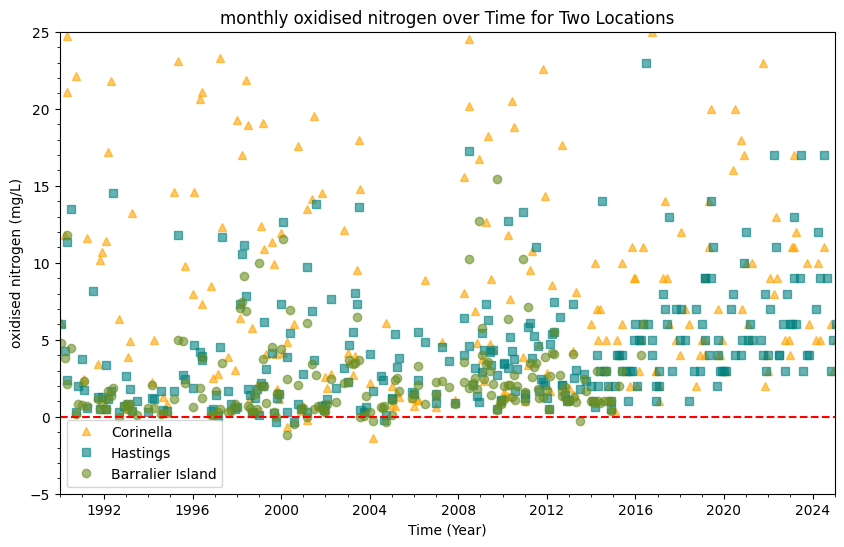

In [406]:
colors = ["orange", "teal", "olivedrab"]

plt.figure(figsize=(10, 6))
for loc, c, marker in zip([loc_1, loc_2, loc_3], colors, ["^", "s", "o"]):
    subset = data[data[loc_col] == loc]
    plt.plot(subset[x_col], subset[y_col], marker, alpha=0.6, color=c, label=loc)

plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.xlabel("Time (Year)")
plt.ylabel("oxidised nitrogen (mg/L)")
plt.legend()
plt.ylim(-5, 25)
plt.xlim(1990, 2025)
plt.minorticks_on()
plt.title("monthly oxidised nitrogen over Time for Two Locations")
plt.axhline(y=0, linestyle ="--",  color="red")
plt.show()


**Figure 1:** Scatter plot of oxidised nitrogen observations over time for Corinella and Hastings, used to visually inspect trends and differences before any formal modelling.

Observations
- slight increase away from 0.

- Variability appears stable for Hastings, but there are significant variations for Corinella, with many outliers.

##Bootstrap:

In [407]:
# Use all oxidised nitrogen from the two locations
X = data[y_col].values

np.random.seed(42)
B = np.random.choice(X, size=(len(X), 1000), replace=True)

bar = np.mean(B, axis=0)
print("Bootstrap means created:", bar.shape)

Bootstrap means created: (1000,)


95% confidence interval: [ 7.96709293 11.6127499 ]


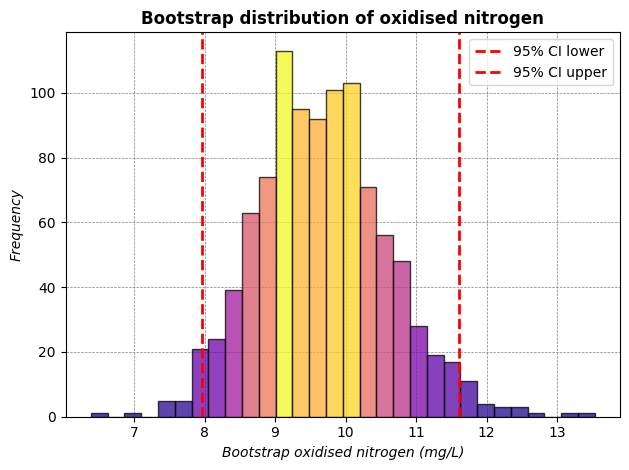

In [408]:
from matplotlib import colors as mcolors

fig, ax = plt.subplots(tight_layout=True)
n, bins, patches = ax.hist(
    bar,
    bins=30,
    edgecolor="k",
    alpha=0.75
)

fracs = n / n.max()
norm = mcolors.Normalize(fracs.min(), fracs.max())
for thisfrac, thispatch in zip(fracs, patches):
    color = plt.cm.plasma(norm(thisfrac))
    thispatch.set_facecolor(color)

ax.set_axisbelow(True)
ax.grid(color="gray", linestyle="dashed", linewidth=0.5)

plt.xlabel("Bootstrap oxidised nitrogen (mg/L)", style="italic")
plt.ylabel("Frequency", style="italic")
plt.title("Bootstrap distribution of oxidised nitrogen", fontweight="bold")

ci = np.percentile(bar, [2.5, 97.5])
print("95% confidence interval:", ci)

plt.axvline(ci[0], color="red", linestyle="dashed", linewidth=2, label="95% CI lower")
plt.axvline(ci[1], color="red", linestyle="dashed", linewidth=2, label="95% CI upper")
plt.legend()
plt.show()


**Interpretation:** The bootstrap distribution shows the uncertainty around the overall oxidised nitrogen. The 95% CI quantifies plausible values for the mean without assuming normality.

##Hypothesis Testing

In [409]:
#SELECT EARLY YEAR GROUPS FROM THE DATASET

data_early = df[(df[x_col] <= 2007)][y_col].dropna()
data_early = data_early[data_early>0]

#SELECT RECENT YEAR GROUPS FROM THE DATASET
data_recent = df[(df[x_col] > 2007)][y_col].dropna()
data_recent = data_recent[data_recent>0]

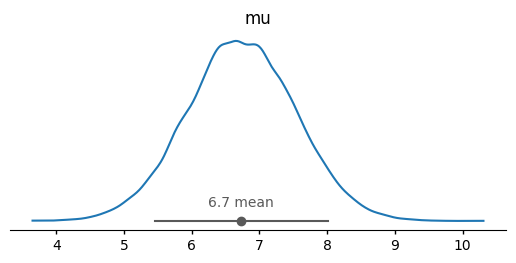

In [410]:
#BAYESIAN MODEL ESTIMATING MEAN CATCH FOR EARLY YEARS

with pm.Model() as early_model:

  # Prior for the mean — Normal centered at your best prior guess with sigma representing the uncertainty in that guess
  mu = pm.Normal("mu", mu = 3, sigma = 2)

  # Prior for std of heights — HalfNormal with a standard deviation of 20.
  sigma = pm.HalfNormal ("sigma", sigma = 2)

  # Likelihood given the data
  obs = pm.Normal ("obs", mu = mu, sigma = sigma, observed = data_early)

   # Obtain 20,000 samples from the posterior
  trace_early = pm.sample(20000, tune = 2000, return_inferencedata = True, progressbar = False)

  # Plot the posterior distribution for the mean
az.plot_dist(trace_early, var_names=["mu"]) # Corrected: Passing InferenceData object with var_names

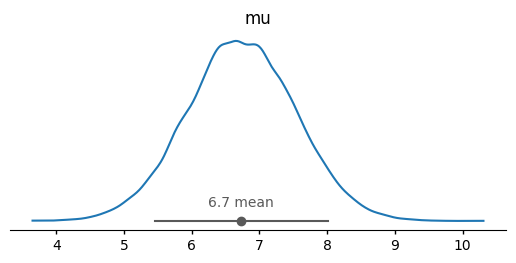

In [411]:
#BAYESIAN MODEL ESTIMATING MEAN CATCH FOR RECENT YEARS

with pm.Model() as recent_model:

  # Prior for the mean — Normal centered at your best prior guess with sigma representing the uncertainty in that guess
  mu = pm.Normal("mu", mu = 3, sigma = 2)

  # Prior for std of heights — HalfNormal with a standard deviation of 20.
  sigma = pm.HalfNormal ("sigma", sigma = 2)

  # Likelihood given the data
  obs = pm.Normal ("obs", mu = mu, sigma = sigma, observed = data_recent)

   # Obtain 20,000 samples from the posterior
  trace_recent = pm.sample(20000, tune = 2000, return_inferencedata = True, progressbar = False)

  # Plot the posterior distribution for the mean
  az.plot_dist(trace_early, var_names=["mu"]) # Corrected: Passing InferenceData object with var_names

In [412]:
#EXTRACT POSTERIOR SAMPLES OF THE MEAN FROM BOTH MODELS

mu_samples_early = trace_early.posterior["mu"].values.flatten()
mu_samples_recent = trace_recent.posterior["mu"].values.flatten()

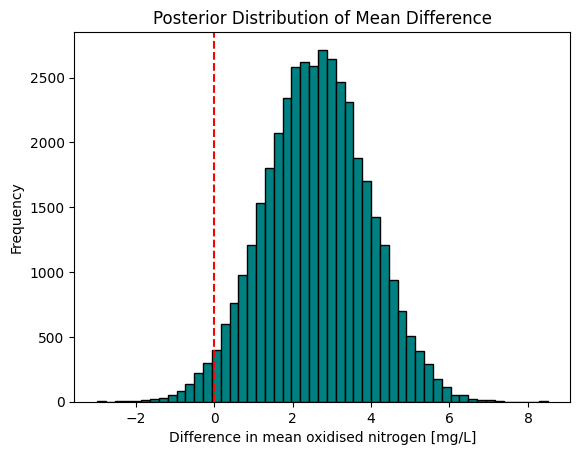

In [434]:
#PLOT DISTRIBUTION OF DIFFERENCE IN MEAN CATCH BETWEEN GROUPS
mu_diff = mu_samples_recent - mu_samples_early

#HISTOGRAM
plt.hist(mu_diff, bins = 51, color="teal", edgecolor="k")
#zero reference line
plt.axvline(0, color="red", linestyle="dashed")

#LABELS
plt.xlabel("Difference in mean oxidised nitrogen [mg/L]")
plt.ylabel("Frequency")
plt.title("Posterior Distribution of Mean Difference")

#SHOW
plt.show() #show plot

In [414]:
#CALCULATE THE 95% HIGHEST DENSITY INTERVAL (CREDIBLE INTERVAL)

az.hdi(mu_diff, prob = 0.95)

array([-0.01345985,  5.1685104 ])

In [415]:
#CALCULATE PROBABILITY THAT RECENT MEAN CATCH IS GREATER THAN EARLY MEAN CATCH

np.mean(mu_diff > 0)

np.float64(0.9757)

In [416]:

# Early and recent data (already cleaned in your notebook)
data_early = df[(df[x_col] <= 2007)][y_col].dropna()
data_early = data_early[data_early > 0]

data_recent = df[(df[x_col] > 2007)][y_col].dropna()
data_recent = data_recent[data_recent > 0]

# Two-sample t-test (Welch's t-test, unequal variances)
t_stat, p_two_sided = stats.ttest_ind(
    data_recent,
    data_early,
    equal_var=False,
    nan_policy='omit'
)

# Convert to one-sided p-value (testing recent > early)
p_one_sided = p_two_sided / 2 if t_stat > 0 else 1 - (p_two_sided / 2)

print("t-statistic:", t_stat)
print("Two-sided p-value:", p_two_sided)
print("One-sided p-value (recent > early):", p_one_sided)

t-statistic: 2.4792174904569215
Two-sided p-value: 0.013400254200335998
One-sided p-value (recent > early): 0.006700127100167999


The probability of the mean catch rate being higher that the previous catch
rate is 0.976, meaning their is a significant increase in the oxidised nitrogen amount between the two data sets and my hypothesis has been correct.

p value is 0.0067 < 0.05, which means we reject the null hypothesis and accept the alternate.

##Scaling and polynomial terms:

In [417]:
# Scale time for numerical stability
data["x_scaled"] = (data[x_col] - data[x_col].mean()) / data[x_col].std()
data["x2_scaled"] = data["x_scaled"] ** 2
data["x3_scaled"] = data["x_scaled"] ** 3

##Bayesian regression models (linear, quadratic, cubic):

In [418]:
# Linear
model_linear = bmb.Model(f"{y_col} ~ x_scaled * {loc_col}", data)
idata_linear = model_linear.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

# Quadratic
model_quadratic = bmb.Model(f"{y_col} ~ x_scaled + x2_scaled * {loc_col}", data)
idata_quadratic = model_quadratic.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

# Cubic
model_cubic = bmb.Model(f"{y_col} ~ x_scaled + x2_scaled + x3_scaled * {loc_col}", data)
idata_cubic = model_cubic.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)


/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(


In [419]:
cmp = az.compare(
    {"linear": idata_linear, "quadratic": idata_quadratic, "cubic": idata_cubic},
    method="BB-pseudo-BMA"
)
cmp

/usr/local/lib/python3.12/dist-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz_stats/loo/helper_loo

,rank,elpd,p,elpd_diff,weight,se,dse,warning
cubic,0,-3600.0,43.3,0.0,0.66,160.0,0.0,True
linear,1,-3600.0,42.5,-1.0,0.30,160.0,1.7,True
quadratic,2,-3600.0,48.7,-4.0,0.04,160.0,2.2,True


The cubic model (rank 0) provided the best fit to the relationship between time and salinity across the two locations.

##Priors and posteriors:

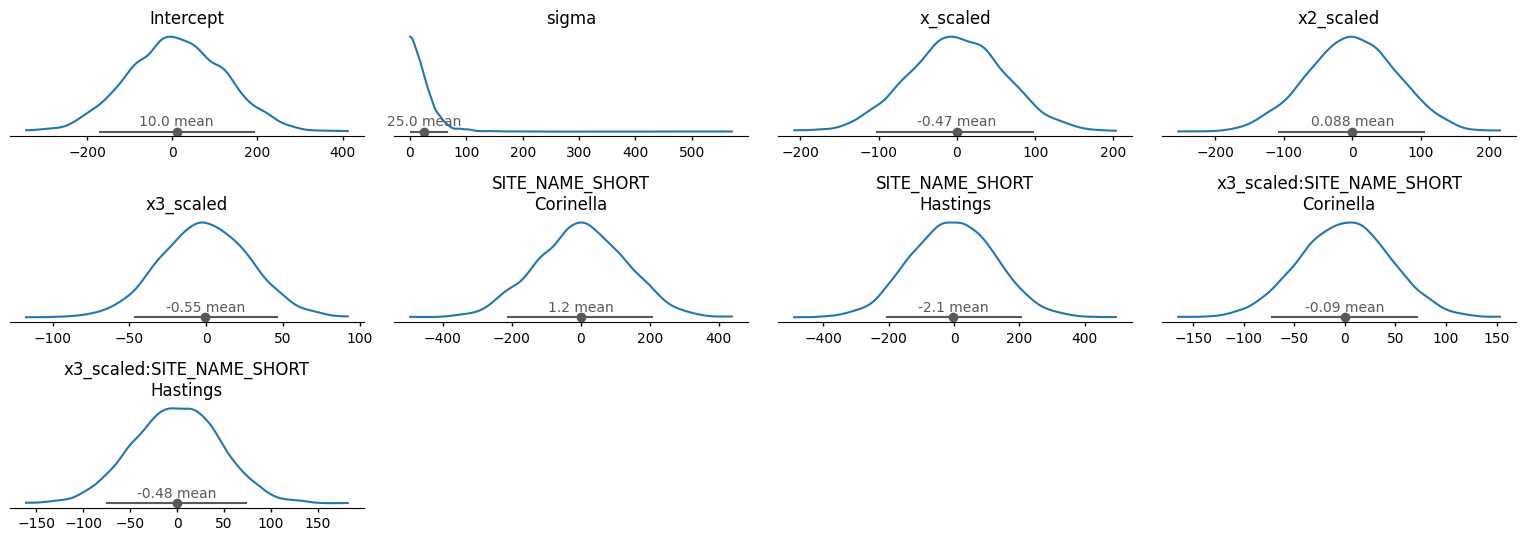

In [420]:
model_cubic.plot_priors()
plt.tight_layout()
plt.show()

 Priors for the cubic regression model. They are broad and centred around zero, reflecting weak prior assumptions about the direction and strength of the oxidised nitrogen trend.

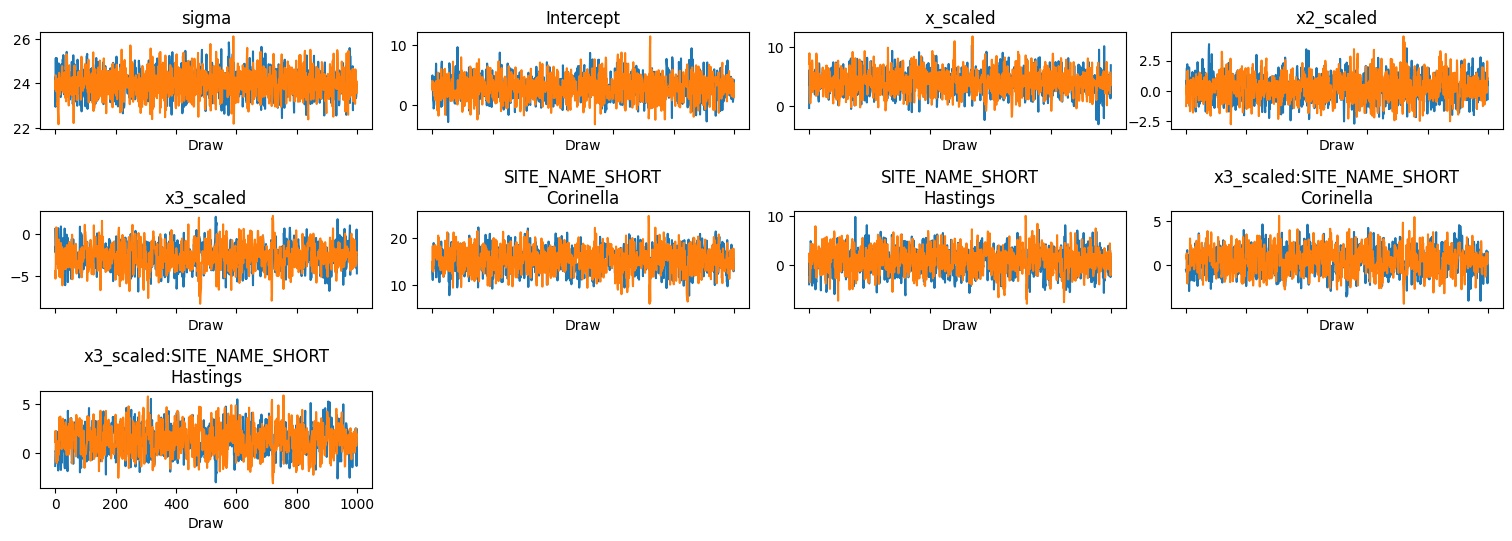

In [421]:
az.plot_trace(idata_cubic)
plt.tight_layout()
plt.show()

**Figure 3:** Posterior trace plots for the cubic model. The chains mix well and converge, suggesting the model has sampled the posterior reliably.

##Predictions + HDIs:

In [422]:
x_range = np.linspace(data[x_col].min(), data[x_col].max(), 200)
x_range_scaled = (x_range - data[x_col].mean()) / data[x_col].std()
x2_range_scaled = x_range_scaled ** 2
x3_range_scaled = x_range_scaled ** 3

In [423]:
# Predictions for location 1
new_data_loc1 = pd.DataFrame({
    "x_scaled": x_range_scaled,
    "x2_scaled": x2_range_scaled,
    "x3_scaled": x3_range_scaled,
    loc_col: loc_1
})
idata_pred_loc1_params = model_cubic.predict(idata_cubic,
                                             data=new_data_loc1,
                                             kind="response_params",
                                             inplace=False)
idata_pred_loc1_resp = model_cubic.predict(idata_cubic,
                                           data=new_data_loc1,
                                           kind="response",
                                           inplace=False)

mu_draws_loc1 = idata_pred_loc1_params.posterior["mu"].stack(draws=("chain","draw")).values.T
pps_draws_loc1 = idata_pred_loc1_resp.posterior_predictive[y_col].stack(draws=("chain","draw")).values.T

posterior_mean_loc1 = pps_draws_loc1.mean(axis=0)
hdi_mean_loc1 = az.hdi(mu_draws_loc1, prob=0.95, axis=0)
hdi_pps_loc1 = az.hdi(pps_draws_loc1, prob=0.95, axis=0)

In [424]:
# Predictions for location 2
new_data_loc2 = pd.DataFrame({
    "x_scaled": x_range_scaled,
    "x2_scaled": x2_range_scaled,
    "x3_scaled": x3_range_scaled,
    loc_col: loc_2
})
idata_pred_loc2_params = model_cubic.predict(idata_cubic,
                                             data=new_data_loc2,
                                             kind="response_params",
                                             inplace=False)
idata_pred_loc2_resp = model_cubic.predict(idata_cubic,
                                           data=new_data_loc2,
                                           kind="response",
                                           inplace=False)

mu_draws_loc2 = idata_pred_loc2_params.posterior["mu"].stack(draws=("chain","draw")).values.T
pps_draws_loc2 = idata_pred_loc2_resp.posterior_predictive[y_col].stack(draws=("chain","draw")).values.T


posterior_mean_loc2 = pps_draws_loc2.mean(axis=0)
hdi_mean_loc2 = az.hdi(mu_draws_loc2, prob=0.95, axis=0)
hdi_pps_loc2 = az.hdi(pps_draws_loc2, prob=0.95, axis=0)

In [425]:
# Predictions for location 3
new_data_loc3 = pd.DataFrame({
    "x_scaled": x_range_scaled,
    "x2_scaled": x2_range_scaled,
    "x3_scaled": x3_range_scaled,
    loc_col: loc_3
})
idata_pred_loc3_params = model_cubic.predict(idata_cubic,
                                             data=new_data_loc3,
                                             kind="response_params",
                                             inplace=False)
idata_pred_loc3_resp = model_cubic.predict(idata_cubic,
                                           data=new_data_loc3,
                                           kind="response",
                                           inplace=False)

mu_draws_loc3 = idata_pred_loc3_params.posterior["mu"].stack(draws=("chain","draw")).values.T
pps_draws_loc3 = idata_pred_loc3_resp.posterior_predictive[y_col].stack(draws=("chain","draw")).values.T


posterior_mean_loc3 = pps_draws_loc3.mean(axis=0)
hdi_mean_loc3 = az.hdi(mu_draws_loc3, prob=0.95, axis=0)
hdi_pps_loc3 = az.hdi(pps_draws_loc3, prob=0.95, axis=0)

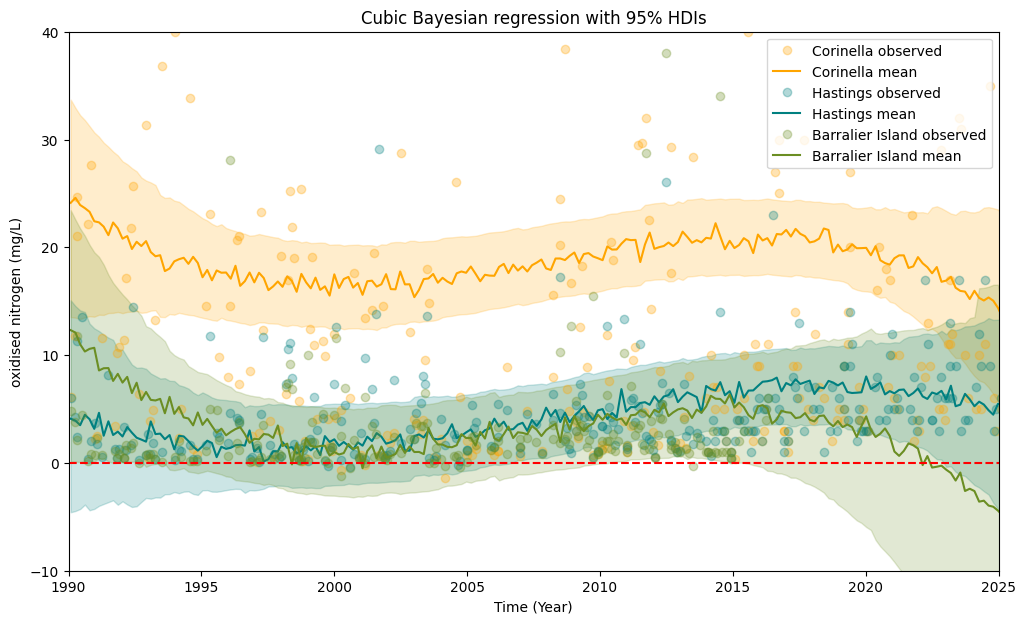

In [426]:
plt.figure(figsize=(12, 7))

for loc, c, mean, hdi_m in [
    (loc_1, colors[0], posterior_mean_loc1, hdi_mean_loc1),
    (loc_2, colors[1], posterior_mean_loc2, hdi_mean_loc2),
    (loc_3, colors[2], posterior_mean_loc3, hdi_mean_loc3),
]:
    subset = data[data[loc_col] == loc]
    plt.plot(subset[x_col], subset[y_col], "o", color=c, alpha=0.3, label=f"{loc} observed")
    plt.plot(x_range, mean, color=c, label=f"{loc} mean")
    plt.fill_between(x_range, hdi_m[:, 0], hdi_m[:, 1], alpha=0.2, color=c)
plt.ylim(-10, 40)
plt.xlim(1990, 2025)
plt.xlabel("Time (Year)")
plt.ylabel("oxidised nitrogen (mg/L)")
plt.title("Cubic Bayesian regression with 95% HDIs")
plt.legend(loc="upper right")
plt.axhline(y=0, linestyle ="--",  color="red")
plt.show()

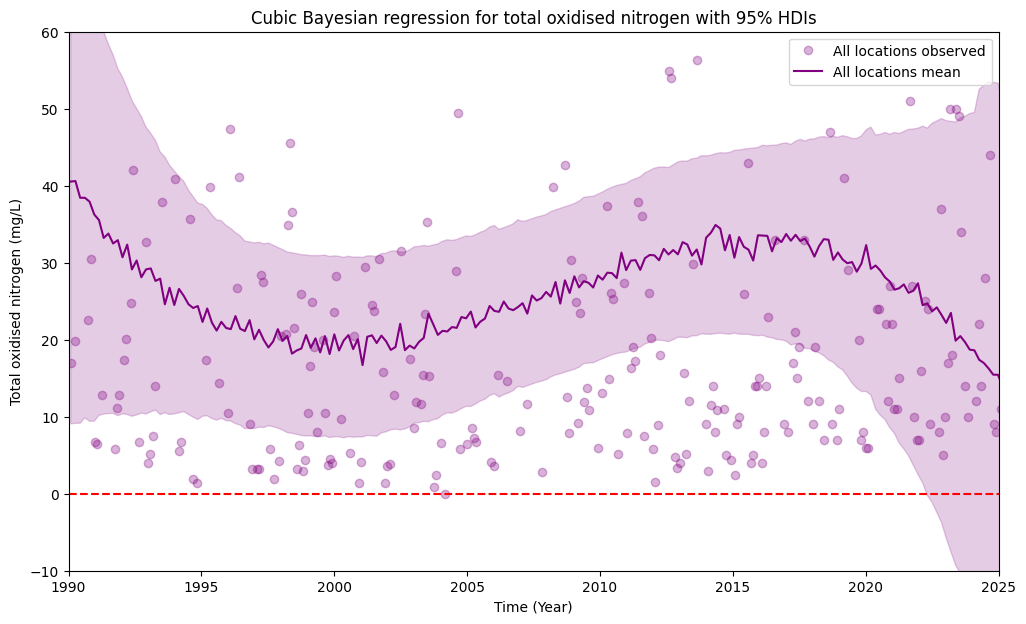

In [427]:
plt.figure(figsize=(12, 7))

# Calculate the total mean and HDI for all three locations
total_posterior_mean = posterior_mean_loc1 + posterior_mean_loc2 + posterior_mean_loc3
total_hdi_lower = hdi_mean_loc1[:, 0] + hdi_mean_loc2[:, 0] + hdi_mean_loc3[:, 0]
total_hdi_upper = hdi_mean_loc1[:, 1] + hdi_mean_loc2[:, 1] + hdi_mean_loc3[:, 1]

# Group by time and sum N_NOX for all locations for observed data
total_observed_data = data.groupby(x_col)[y_col].sum().reset_index()

# Plot the total observed data
plt.plot(total_observed_data[x_col], total_observed_data[y_col], "o", color='purple', alpha=0.3, label="All locations observed")

# Plot the total mean and HDI
plt.plot(x_range, total_posterior_mean, color='purple', label="All locations mean")
plt.fill_between(x_range, total_hdi_lower, total_hdi_upper, alpha=0.2, color='purple')

plt.ylim(-10, 60) # Adjusted y-limit as the sum will be higher
plt.xlim(1990, 2025)
plt.xlabel("Time (Year)")
plt.ylabel("Total oxidised nitrogen (mg/L)") # Changed label to reflect total
plt.title("Cubic Bayesian regression for total oxidised nitrogen with 95% HDIs") # Changed title
plt.legend(loc="upper right")
plt.axhline(y=0, linestyle ="--",  color="red")
plt.show()

**Figure 4:** Fitted cubic regression curves with 95% HDIs for both locations. The model captures gradual changes in oxidised nitrogen over time and quantifies uncertainty around the trend.

##Conclusion:

#**References:**


1. EPA Western Port Water Quality Data 1990 - 2025 - Victorian Government Data Directory. (2025). Vic.gov.au. https://discover.data.vic.gov.au/dataset/epa-western-port-water-quality-data

2. French Island National Park. (n.d.). Western Port [Map]. Wikimedia Commons. https://en.wikipedia.org/wiki/Western_Port#/media/File:French_Island_National_Park.png

3. How we monitor water quality. (2025, June 4). Vic.gov.au. https://www.epa.vic.gov.au/how-we-monitor-water-quality

4. Melbourne Water. (2011). Understanding the Western Port Environment A summary of current knowledge and priorities for future research. https://www.melbournewater.com.au/sites/default/files/2018-02/Understanding_the_Western_Port_Environment_0.pdf

5. Queensland Government. (2013, August 29). Nitrogen oxides | Air pollutants. Www.qld.gov.au; Queensland Government. https://www.qld.gov.au/environment/management/monitoring/air/air-pollution/pollutants/nitrogen-oxides